In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()


Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


In [3]:
movies = pd.read_csv("movies.csv")
ratings=pd.read_csv("ratings.csv")

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
movie_data=ratings.merge(movies,on="movieId")

In [8]:
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [9]:
romcoms=movies[
    movies["genres"].str.contains("Romance")&
    movies["genres"].str.contains("Comedy")
]

In [10]:
len(romcoms)

884

In [11]:
romcoms.head()

,movieId,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
6,7,Sabrina (1995),Comedy|Romance
10,11,"American President, The (1995)",Comedy|Drama|Romance
35,39,Clueless (1995),Comedy|Romance


In [12]:
romcom_data=ratings.merge(romcoms,on="movieId")

In [13]:
romcom_data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

,rating
title,
Forrest Gump (1994),329
True Lies (1994),178
Shrek (2001),170
Groundhog Day (1993),143
"Princess Bride, The (1987)",142
Pretty Woman (1990),135
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",120
Ghost (1990),115
Sleepless in Seattle (1993),106


In [17]:
ratings_mean_count=pd.DataFrame(romcom_data.groupby("title")["rating"].mean())
ratings_mean_count.sort_values(by="rating", ascending=False).head(10)

,rating
title,
All the Vermeers in New York (1990),5.0
All Yours (2016),5.0
"Thousand Clowns, A (1965)",5.0
Unicorn City (2012),5.0
Watching the Detectives (2007),5.0
Laggies (2014),5.0
"One I Love, The (2014)",5.0
Strictly Sexual (2008),5.0
Spellbound (2011),5.0


In [18]:
movie_stats = romcom_data.groupby("title").agg(
    Average_Rating=("rating", "mean"),
    Number_of_Ratings=("rating", "count")
)

movie_stats = movie_stats[
    movie_stats["Number_of_Ratings"] >= 20
]

movie_stats.sort_values(
    "Average_Rating",
    ascending=False
).head(10)

,Average_Rating,Number_of_Ratings
title,,
"Philadelphia Story, The (1940)",4.310345,29
Harold and Maude (1971),4.288462,26
"Princess Bride, The (1987)",4.232394,142
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",4.183333,120
Forrest Gump (1994),4.164134,329
Life Is Beautiful (La Vita è bella) (1997),4.147727,88
Manhattan (1979),4.106061,33
Singin' in the Rain (1952),4.074468,47
"Graduate, The (1967)",4.063291,79


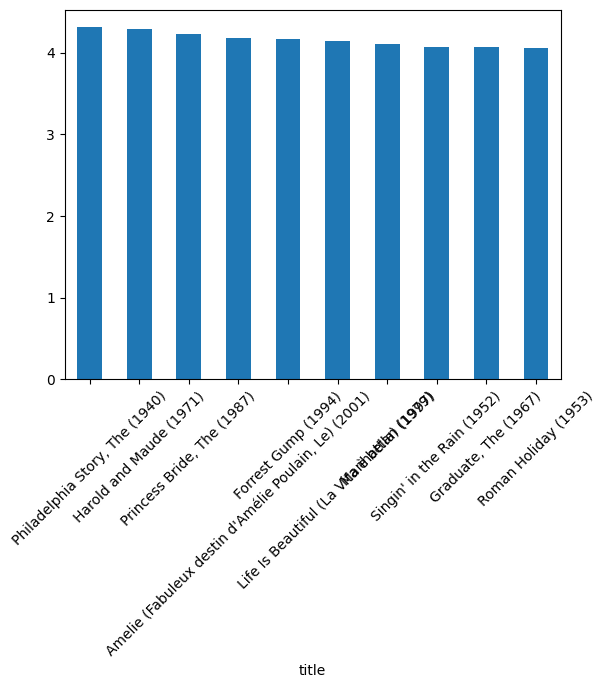

In [19]:
top = movie_stats.sort_values(
    "Average_Rating",
    ascending=False
).head(10)

top["Average_Rating"].plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

In [20]:
user_movie_matrix = romcom_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

user_movie_matrix.head()


title,(500) Days of Summer (2009),10 (1979),10 Items or Less (2006),10 Things I Hate About You (1999),10 Years (2011),100 Girls (2000),101 Reykjavik (101 Reykjavík) (2000),13 Going on 30 (2004),2 Days in Paris (2007),20 Dates (1998),...,Working Girl (1988),"World According to Garp, The (1982)",You Are the Apple of My Eye (2011),You Can't Take It with You (1938),You Will Meet a Tall Dark Stranger (2010),You'll Never Get Rich (1941),You've Got Mail (1998),"Yours, Mine and Ours (2005)",Youth in Revolt (2009),Zack and Miri Make a Porno (2008)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
user_movie_filled = user_movie_matrix.fillna(0)

user_movie_filled.head()


title,(500) Days of Summer (2009),10 (1979),10 Items or Less (2006),10 Things I Hate About You (1999),10 Years (2011),100 Girls (2000),101 Reykjavik (101 Reykjavík) (2000),13 Going on 30 (2004),2 Days in Paris (2007),20 Dates (1998),...,Working Girl (1988),"World According to Garp, The (1982)",You Are the Apple of My Eye (2011),You Can't Take It with You (1938),You Will Meet a Tall Dark Stranger (2010),You'll Never Get Rich (1941),You've Got Mail (1998),"Yours, Mine and Ours (2005)",Youth in Revolt (2009),Zack and Miri Make a Porno (2008)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
movie_similarity = cosine_similarity(user_movie_filled.T)


In [24]:
similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_filled.columns,
    columns=user_movie_filled.columns
)


In [25]:
similarity_df.head()


title,(500) Days of Summer (2009),10 (1979),10 Items or Less (2006),10 Things I Hate About You (1999),10 Years (2011),100 Girls (2000),101 Reykjavik (101 Reykjavík) (2000),13 Going on 30 (2004),2 Days in Paris (2007),20 Dates (1998),...,Working Girl (1988),"World According to Garp, The (1982)",You Are the Apple of My Eye (2011),You Can't Take It with You (1938),You Will Meet a Tall Dark Stranger (2010),You'll Never Get Rich (1941),You've Got Mail (1998),"Yours, Mine and Ours (2005)",Youth in Revolt (2009),Zack and Miri Make a Porno (2008)
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),1.000000,0.05072,0.125232,0.326122,0.101181,0.086407,0.0,0.328675,0.182125,0.000000,...,0.088963,0.087556,0.0,0.000000,0.101181,0.000000,0.199528,0.263217,0.298783,0.401963
10 (1979),0.050720,1.00000,0.000000,0.000000,0.501280,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.138440,0.0,0.000000,0.501280,0.000000,0.000000,0.000000,0.203706,0.135781
10 Items or Less (2006),0.125232,0.00000,1.000000,0.000000,0.000000,0.000000,0.0,0.124604,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.259665,0.000000,0.149002
10 Things I Hate About You (1999),0.326122,0.00000,0.000000,1.000000,0.000000,0.237017,0.0,0.354539,0.166524,0.038457,...,0.244625,0.149891,0.0,0.047612,0.000000,0.092513,0.305906,0.000000,0.126569,0.280660
10 Years (2011),0.101181,0.50128,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.276172,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.406371,0.270868


In [28]:
def recommend_movies(movie_name):
  if movie_name not in similarity_df.columns:
    print("Sorry! Not present.")
    return
  similarity_scores=similarity_df[movie_name]
  similar_movies=similarity_scores.sort_values(ascending=False)
  similar_movies = similar_movies.drop(movie_name)

    # Show the top 5 recommendations
  print(f"\n💕 Because you liked '{movie_name}', you might also enjoy:\n")

  for movie in similar_movies.head(5).index:
      print("💖", movie)




In [35]:
print("Enter a movie name:")
movie_name = input()
recommend_movies(movie_name)

Enter a movie name:
(500) Days of Summer (2009)

💕 Because you liked '(500) Days of Summer (2009)', you might also enjoy:

💖 Crazy, Stupid, Love. (2011)
💖 Scott Pilgrim vs. the World (2010)
💖 Holiday, The (2006)
💖 Hitch (2005)
💖 Juno (2007)
